# Drive mount to get the data for the model (Images)

# Import relevant libraries for generating and viewing data for the model

Additionally create the routes to the main directory and the train and test directories.

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [62]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [63]:
base_dir = 'Hongos'
train_dir = os.path.join(base_dir,'train')
cat1_dir = os.path.join(train_dir, 'edible mushroom sporocap')
cat2_dir = os.path.join(train_dir, 'edible sporocap')
cat3_dir = os.path.join(train_dir, 'poisonous mushroom sporocap')
cat4_dir = os.path.join(train_dir, 'poisonous sporocap')
test_dir = os.path.join(base_dir, 'test')

In [64]:
tf.random.set_seed(42)
np.random.seed(42)

In [65]:
# GPU support
print(f"Num GPUs Available: {len(tf.config.experimental.list_physical_devices('GPU'))}")

Num GPUs Available: 0


In [66]:
# Set GPU

gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
  try:
    tf.config.experimental.set_virtual_device_configuration(
        gpus[0],
        [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=1024)])
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    print(e)

Give parameters for the image data generator according to the characteristics wanted for the model.

In [67]:
train_datagen = ImageDataGenerator(
  rescale = 1./255,
  rotation_range = 20,
  width_shift_range = 0.2,
  height_shift_range = 0.2,
  shear_range = 0.2,
  zoom_range = 0.2,
  horizontal_flip = True,
  validation_split = 0.2
)

In [68]:
def augment_class_images(input_dir, output_dir, target_count):
    os.makedirs(output_dir, exist_ok=True)
    image_files = os.listdir(input_dir)
    current_count = len(image_files)
    images_needed = target_count - current_count
    images = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    images.sort()

    print(f"Augmenting {images_needed} images for {input_dir}...")
    if images_needed <= 0:
        return

    i = 0
    img_idx = 0
    while i < images_needed:
        img_name = images[img_idx]
        img_idx = (img_idx + 1) % current_count
        img_path = os.path.join(input_dir, img_name)
        img = load_img(img_path)  # Load image
        x = img_to_array(img)  # Convert to numpy array
        x = x.reshape((1,) + x.shape)  # Reshape for ImageDataGenerator

        # Generate augmented images
        for batch in train_datagen.flow(x, batch_size=1, save_to_dir=output_dir, save_prefix='zaug', save_format='jpg'):
            i += 1
            break

In [69]:
augment_class_images(cat1_dir, cat1_dir, 1285)
augment_class_images(cat2_dir, cat2_dir, 1285)
augment_class_images(cat3_dir, cat3_dir, 1285)
augment_class_images(cat4_dir, cat4_dir, 1285)

Augmenting 1 images for Hongos\train\edible mushroom sporocap...
Augmenting 1 images for Hongos\train\edible sporocap...
Augmenting 0 images for Hongos\train\poisonous mushroom sporocap...
Augmenting 0 images for Hongos\train\poisonous sporocap...


Give information about the images for the generator (classes, route, size, class mode, etc.)

In [70]:
train_generator = train_datagen.flow_from_directory(
  train_dir,
  target_size = (150, 150),
  batch_size = 8,
  classes=['edible mushroom sporocap', 'edible sporocap', 'poisonous mushroom sporocap', 'poisonous sporocap'],
  class_mode ='categorical',
  subset = 'training',
  shuffle = True
  #follow_links=True
)

valid_generator = train_datagen.flow_from_directory(
  train_dir,
  target_size = (150, 150),
  batch_size = 8,
  classes=['edible mushroom sporocap', 'edible sporocap', 'poisonous mushroom sporocap', 'poisonous sporocap'],
  class_mode ='categorical',
  subset = 'validation',
  shuffle = True
  #follow_links=True
)

Found 4112 images belonging to 4 classes.
Found 1026 images belonging to 4 classes.


Plot some generated images to check if it is working correctly

In [71]:
class_dirs = {
    'edible mushroom sporocap': cat1_dir,
    'edible sporocap': cat2_dir,
    'poisonous mushroom sporocap': cat3_dir,
    'poisonous sporocap': cat4_dir
}

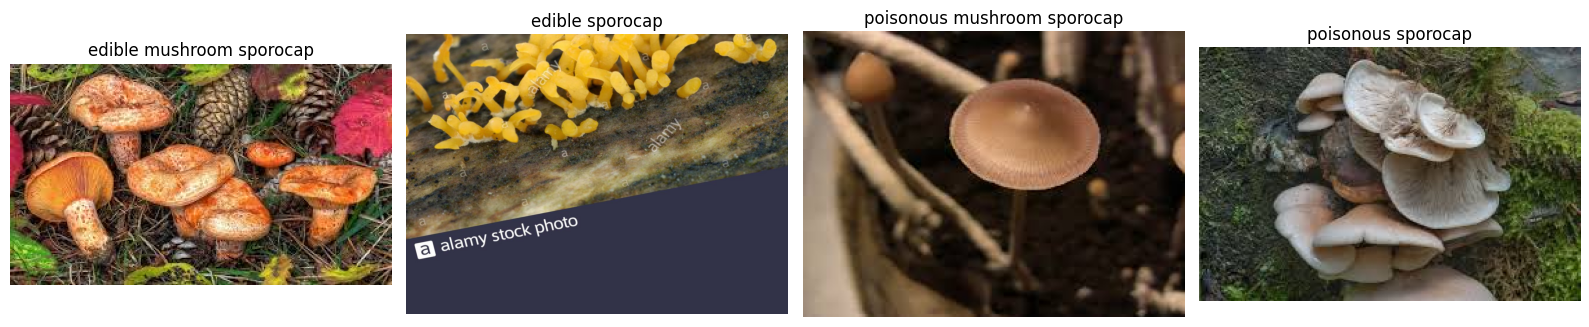

In [72]:
plt.figure(figsize=(16, 8))

for idx, (class_name, class_path) in enumerate(class_dirs.items()):
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not images:
        print(f"No images found in {class_path}")
        continue

    image_file = random.choice(images)
    image_path = os.path.join(class_path, image_file)

    img = load_img(image_path)
    plt.subplot(1, 4, idx  + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [73]:
class_names = list(train_generator.class_indices.keys())
print(class_names)

['edible mushroom sporocap', 'edible sporocap', 'poisonous mushroom sporocap', 'poisonous sporocap']


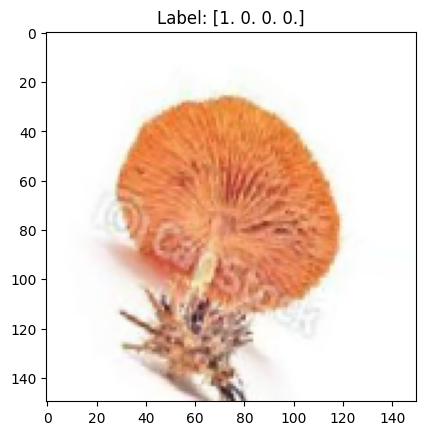

In [74]:
images, labels = next(train_generator)

plt.imshow(images[0])
plt.title(f"Label: {labels[0]}")
plt.show()

# Import relevant libraries for training the model

In [75]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

Establish the configuration for the model (Conv2D, input shape, number of layers, activation, etc.)

In [76]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [77]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(150, 150, 3)
)

base_model.trainable = False
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [78]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

Compile the model and train it using the shuffled generated images

In [ ]:
model.compile(
    loss='categorical_crossentropy',
	optimizer=optimizers.Adam(learning_rate=1e-3),
	metrics=['acc']
)

In [ ]:
history = model.fit(
  train_generator, 
  validation_data = train_generator,
  epochs = 5
)

Epoch 1/5
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - acc: 0.2422 - loss: 1.7056

Test the model accuracy using generated test images

In [ ]:
test_datagen = ImageDataGenerator(1./255)
test_generator = test_datagen.flow_from_directory(
					test_dir,
					target_size = (150, 150),
					batch_size = 8,
					class_mode= 'categorical')

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

test_loss, test_acc = model.evaluate(test_generator, steps = 25)
print('\ntest acc :\n', test_acc)

Found 300 images belonging to 4 classes.


c:\Users\diego\anaconda3\envs\tf-cpu\lib\site-packages\keras\src\legacy\preprocessing\image.py:1263: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - acc: 0.2564 - loss: 7.6458

test acc :
 0.2549999952316284


[Text(0.5, 0, 'Epochs'), Text(0, 0.5, 'Accuracy')]

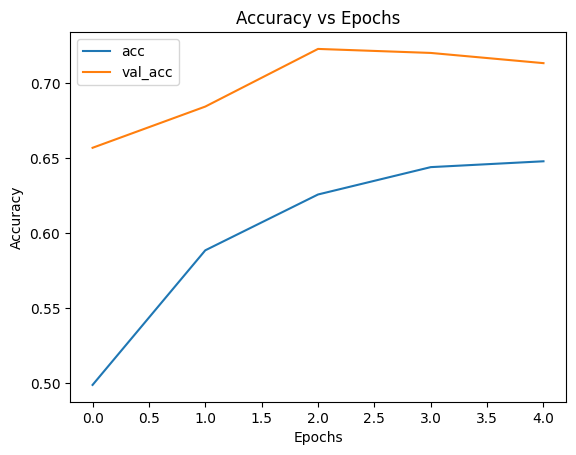

In [ ]:
frame = pd.DataFrame(history.history)

acc_plot = frame.plot(y=["acc", "val_acc"], title="Accuracy vs Epochs", legend=True)
acc_plot.set(xlabel="Epochs", ylabel="Accuracy")

[Text(0.5, 0, 'Epochs'), Text(0, 0.5, 'Loss')]

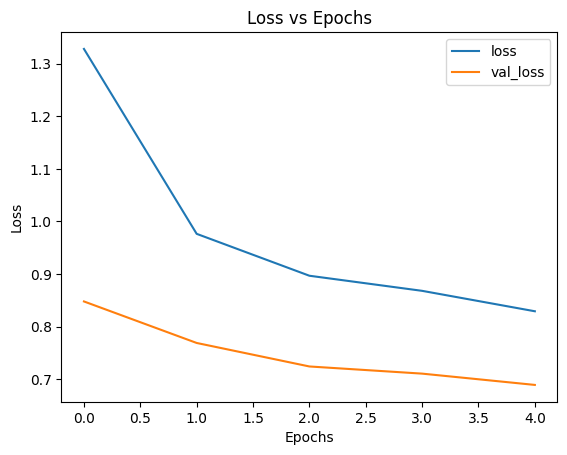

In [ ]:
acc_plot = frame.plot(y=["loss", "val_loss"], title = "Loss vs Epochs",legend=True)
acc_plot.set(xlabel="Epochs", ylabel="Loss")

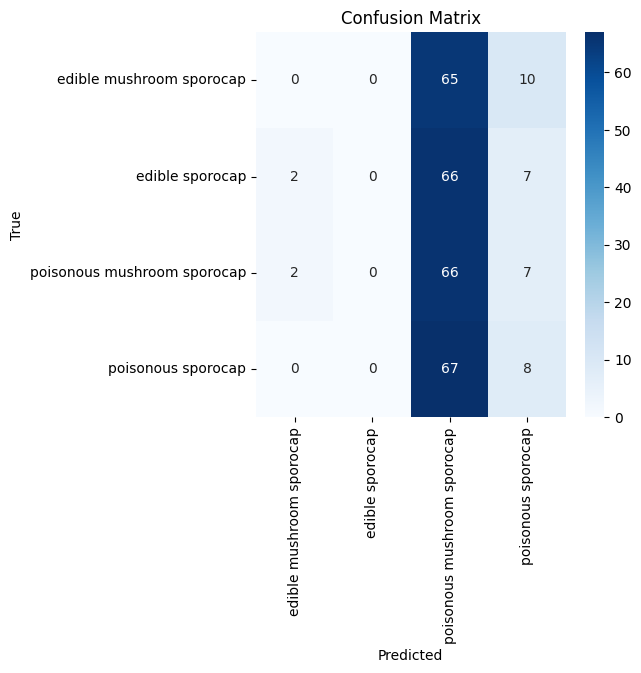

In [ ]:
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# Plotting the confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

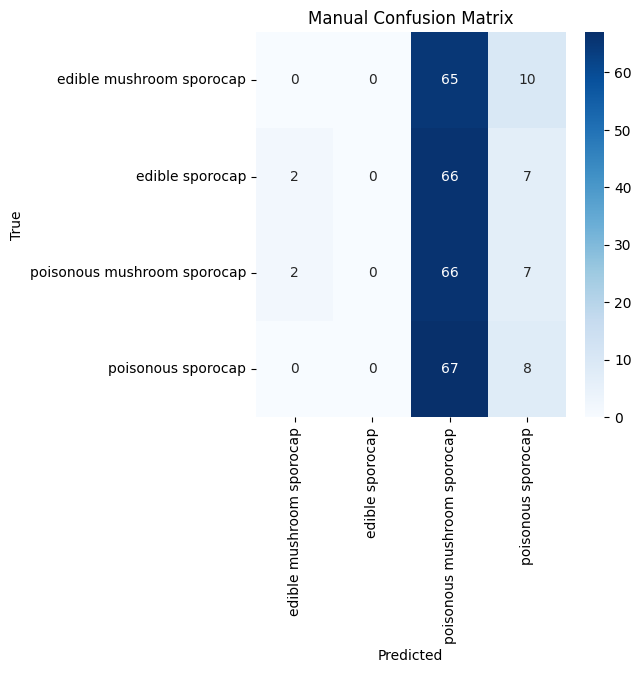

In [ ]:
c_m = [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]

for i in range(len(test_generator.classes)):
  if predicted_classes[i] == 0:
    if predicted_classes[i] == test_generator.classes[i]:
      c_m[0][0] += 1
    elif test_generator.classes[i] == 1:
      c_m[1][0] += 1
    elif test_generator.classes[i] == 2:
      c_m[2][0] += 1
    else:
      c_m[3][0] += 1
  elif predicted_classes[i] == 1:
    if predicted_classes[i] == test_generator.classes[i]:
      c_m[1][1] += 1
    elif test_generator.classes[i] == 0:
      c_m[0][1] += 1
    elif test_generator.classes[i] == 2:
      c_m[2][1] += 1
    else:
      c_m[3][1] += 1
  elif predicted_classes[i] == 2:
    if predicted_classes[i] == test_generator.classes[i]:
      c_m[2][2] += 1
    elif test_generator.classes[i] == 0:
      c_m[0][2] += 1
    elif test_generator.classes[i] == 1:
      c_m[1][2] += 1
    else:
      c_m[3][2] += 1
  else:
    if predicted_classes[i] == test_generator.classes[i]:
      c_m[3][3] += 1
    elif test_generator.classes[i] == 0:
      c_m[0][3] += 1
    elif test_generator.classes[i] == 1:
      c_m[1][3] += 1
    else:
      c_m[2][3] += 1

plt.figure(figsize=(5, 5))
sns.heatmap(c_m, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Manual Confusion Matrix')
plt.show()